## Market Microstructure

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
torch.manual_seed(10)
# Trading and Market Parameters
params = {
    'S0': 45.0,     # Initial asset price
    'sigma': 0.6,   # Daily volatility -> annual volatility of 21%
    'T': 63,        # Total time horizon (e.g., one trading quarter)
    'F': 900000000, # Target notion/fund to spend
    'gamma': 1e-6,  # Risk aversion coefficient (penalizes variance)
    'alpha': 0.25,  # Reward coefficient for "Profit"
    'beta': 0.05,   # Penalty coefficient for "Loss"
    'kappa': 0.005, # Execution haircut/threshold parameter
    'n_trajectories': 2048,  # Number of Monte Carlo paths per training step
}

V = 4000000             # Market Average Daily Volume (ADV) for liquidity impact
C = 0.01/params['F']    # Initial penalty coefficient for under-utilization
pretraining = 100       # Epochs to ignore risk/variance to stabilize initial weights


def generate_torch_price_paths(p):
    """
    Generates simple Arithmetic Brownian Motion paths: S_t = S_{t-1} + sigma * epsilon
    """
    S = torch.zeros((p['T'] + 1, p['n_trajectories']))
    S[0] = p['S0']
    for t in range(1, p['T'] + 1):
        epsilon = torch.randn(p['n_trajectories'])
        S[t] = S[t-1] + p['sigma'] * epsilon
    return S


def generate_gbm_paths_vectorised(p):
    """
    Generates Geometric Brownian Motion (GBM) paths using vectorized operations for speed
    """
    device = p.get("device", "cpu")

    S0 = p["S0"]
    mu = 0.000198         # Drift (expected return)
    sigma = 0.0132        # Daily volatility percentage

    T, n = p["T"], p["n_trajectories"]

    drift = (mu - 0.5 * sigma**2)
    diffusion = sigma

    Z = torch.randn(T, n, device=device)
    log_returns = drift + diffusion * Z  # S_t depends on sum of previous log returns

    log_paths = torch.cumsum(log_returns, dim=0)

    S = torch.zeros((T + 1, n), device=device)
    S[0] = S0
    S[1:] = S0 * torch.exp(log_paths)

    return S


def specialized_S_function(x):
    """
    Custom activation mapping (-inf, inf) to [0, 1] to represent exercise probability
    """
    sigmoid_part = 2.0 / (1.0 + torch.exp(-x)) - 0.5
    sigmoid_part = 2.0 / (1.0 + torch.exp(-x)) - 0.5
    return torch.clamp(sigmoid_part, min=0.0, max=1.0)


def calculate_liquidity_cost(rho):
    """
    Market impact model: cost increases non-linearly with trade size relative to ADV
    """
    return torch.abs(rho)**(1.75)*0.1


def l(x, epoch):
    """
    Calculates the Final PnL based on market average price vs execution price
    """
    coeff = 0.01 / params['F'] if epoch < pretraining else 2e-9
    return coeff * (x**2)


def calculate_pnl_step(X, q, A_market, p, epoch):
    """
    Calculates the Final PnL based on market average price vs execution price
    """
    # Excess returns vs the benchmark (A_market - kappa*S0)
    excess = q * (A_market - p['kappa'] * p['S0']) - p['F']
    profit_part = p['alpha'] * torch.clamp(excess, min=0)
    loss_part = p['beta'] * torch.clamp(-excess, min=0)
    # Total PnL = Incentives - Penalty for not spending enough
    return -l(p['F']-X, epoch)+profit_part - loss_part


class TradingPolicy(nn.Module):
    """Neural Network defining the Trading Strategy"""
    def __init__(self):
        super(TradingPolicy, self).__init__()

        # v_net: Trade Velocity
        # Inputs: [time, price_rel, avg_price_rel, cash_spent_rel, inventory_rel]
        self.v_net = nn.Sequential(
            nn.Linear(5, 50),
            nn.ReLU(),
            nn.Linear(50, 1)

        )

        # p_net: Determines 'When to stop'
        self.p_net = nn.Sequential(
            nn.Linear(4, 50),
            nn.ReLU(),
            nn.Linear(50, 1)
        )

        # Initialization to prevent early-stage vanishing gradients
        nn.init.constant_(self.p_net[2].bias, 0.1)
        nn.init.xavier_uniform_(self.p_net[2].weight)

        # nu: Scalable parameter for the exercise trigger sensitivity
        self.nu = nn.Parameter(torch.tensor([1.0]))

    def forward_v(self, state_v):
        """state_v: (batch, 5) """
        return self.v_net(state_v).squeeze(-1)

    def forward_p(self, state_p):
        """state_p: (batch, 4) """
        return self.p_net(state_p).squeeze(-1)


def trainModel(params, traj_func):
    model = TradingPolicy()
    # Optimizer with different learning rates for different functional components
    optimizer = torch.optim.Adam([
        {'params': model.v_net.parameters(), 'lr': 1e-2},
        {'params': model.p_net.parameters(), 'lr': 1e-3},
        {'params': [model.nu], 'lr': 1e-4},
    ], eps=1e-8)
    
    A_market = torch.zeros(params['n_trajectories'])
    torch.manual_seed(123)
    for epoch in range(5000):
        S = traj_func({**params, 'n_trajectories': params['n_trajectories']})
        N = params['T']
        F = params['F']
        S0 = params['S0']

        X = torch.zeros(params['n_trajectories'])
        q = torch.zeros(params['n_trajectories'])
        v_n = torch.zeros(params['n_trajectories'])

        all_p_n = []
        all_pnl_n = []
        A_market = torch.zeros(params['n_trajectories'])

        # Simulation Loop
        for n in range(1, N + 1):

            A_market = A_market * (n-1) / n + S[n] / n     # Incremental average

            # Calculate trade velocity (v_n)
            state = torch.stack([
                torch.full((params['n_trajectories'],), n / params['T'] - 0.5),
                S[n] / S0 - 1.0,
                (A_market - S[n]) / S0,
                X / F - 0.5,
                q * S0 / F - 0.5
            ], dim=1)

            v_tilde = model.forward_v(state)
            rate_multiplier = torch.clamp(
                (1 + v_tilde) / max(N - n, 1), min=0.0, max=1.0)
            v_n = torch.where(X < F,
                              rate_multiplier * (F - X) / S[n],
                              torch.zeros_like(rate_multiplier))

            state_p = torch.stack([
                torch.full((params['n_trajectories'],), n / N - 0.5),
                S[n] / S0 - 1.0,
                (A_market - S[n]) / S0,
                q * S0 / F - 0.5,
            ], dim=1)
            if 22 <= n <= 62:
                x = model.nu * (X / F - model.forward_p(state_p))
                p_n = specialized_S_function(x)

            elif n == params['T']:
                p_n = torch.ones(params['n_trajectories']) # Must exercise on the final day
            else:
                p_n = torch.zeros(params['n_trajectories'])

            # Update State: Cash spent includes price + liquidity impact
            X = X + v_n * S[n] + calculate_liquidity_cost(v_n / V) * V
            q = q + v_n
            
            all_p_n.append(p_n)
            all_pnl_n.append(calculate_pnl_step(X, q, A_market, params, epoch))

        # --- Policy Gradient / Probability Logic ---
        all_p_n = torch.stack(all_p_n, dim=1)
        all_pnl_n = torch.stack(all_pnl_n, dim=1)
        # Survival probability: Probability we haven't exercised before time 'n'
        not_exercised = 1 - all_p_n
        cum_prod = torch.cumprod(not_exercised + 1e-8, dim=1)

        survival = torch.cat([
            torch.ones(params['n_trajectories'], 1).to(all_p_n.device),
            cum_prod[:, :-1]
        ], dim=1)

        weights = survival * all_p_n
        weighted_pnl = weights * all_pnl_n  # (batch, T)
        path_pnls = weighted_pnl.sum(dim=1)  # (batch,)
        expected_pnl = path_pnls.mean()

        # E[PnL^2]
        weighted_pnl2 = weights * (all_pnl_n ** 2)  # (batch, T)
        expected_pnl2 = weighted_pnl2.sum(dim=1).mean()

        # Var[PnL] = E[PnL^2] - E[PnL]^2
        variance_pnl = expected_pnl2 - expected_pnl ** 2

        # Objective Function
        gamma = params['gamma']
        if epoch < pretraining:
            gamma = 0
        objective = expected_pnl - (gamma / 2) * variance_pnl

        loss = -objective
        optimizer.zero_grad()
        loss.backward()
        # Gradient Clipping to prevent "Exploding Gradients" in deep nets
        torch.nn.utils.clip_grad_norm_(model.p_net.parameters(), max_norm=1.0)

        optimizer.step()
        if epoch % 100 == 0:
            print(
                f"Epoch {epoch}, Loss: {loss.item():.4f}, Mean PnL: {expected_pnl.item():.4f}, Var PnL: {variance_pnl.item():.4f}")
    return model

In [2]:
def plot_strategy_results(model, params, traj_func,seed=123):
    """
    Simulates and visualizes the trained policy on a single price trajectory.
    It tracks the buying speed and the moment the model decides to 'exercise'.
    """
    # 1. Setup and Path Generation
    torch.manual_seed(seed)
    # Generate exactly one path for visualization purposes
    S = traj_func({**params, 'n_trajectories': 1})
    N = params['T']
    F = params['F']
    S0 = params['S0']
    v_his = []
    p_his = []

    # Lists to store history for plotting
    X_history = [0.0]
    A_history = [params['S0']]

    # Initialize state variables
    X, q, A_market = torch.tensor(
        [0.0]), torch.tensor([0.0]), torch.tensor([S0])
    v_n = torch.tensor([0.0])
    model.eval()
    with torch.no_grad():
        for n in range(1, N + 1):

            A_market = A_market * (n-1) / n + S[n] / n

            state = torch.stack([
                torch.full((1,), n / params['T'] - 0.5),
                S[n] / params['S0'] - 1.0,
                (A_market - S[n]) / params['S0'],
                X / F - 0.5,
                q * params['S0'] / F - 0.5
            ], dim=1)

            state_p = torch.stack([
                torch.full((1,), n / params['T'] - 0.5),
                S[n] / params['S0'] - 1.0,
                (A_market - S[n]) / params['S0'],
                q * params['S0'] / F - 0.5,
            ], dim=1)

            v_tilde = model.forward_v(state)
            rate_multiplier = torch.clamp(
                (1 + v_tilde) / max(params['T'] - n, 1), min=0.0, max=1.0)
            v_n = torch.where(X < F,
                              rate_multiplier * (F - X) / S[n],
                              torch.zeros_like(rate_multiplier))

            # --- Exercise Logic ---
            if 22 <= n <= 62 and np.random.uniform(0, 1) < specialized_S_function(model.nu * (X / F - model.forward_p(state_p))):
                break
            if 22 <= n <= 62:
                p_his.append(specialized_S_function(
                    model.nu * (X / F - model.forward_p(state_p))).item())
            X = X + v_n * S[n] + calculate_liquidity_cost(v_n / V) * V
            q = q + v_n
            v_his.append(v_tilde.item())
            X_history.append(X.item())
            A_history.append(A_market.item())
        for _ in range(len(A_history), N+1):
            A_market = A_market * (n-1) / n + S[n] / n
            A_history.append(A_market.item())

    with torch.no_grad():
        print(f"Stopping day: {n}")

    # 3. Visualization
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- Plot 1: Price Trajectory ---
    days = range(N + 1)
    ax1.plot(days, S.squeeze().numpy(), color='black', label='Spot')
    ax1.plot(days, A_history, color='black', linestyle=':', label='Average')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Price')
    ax1.set_title('Price trajectory')
    if days[len(X_history)-1]!=63:
        ax1.grid(True, alpha=0.2)
        ax1.axvline(x=days[len(X_history)-1], color='red', linestyle='--', linewidth=2, label=f'Early exercise at Day {days[len(X_history)-1]}')
    ax1.legend()

    # --- Plot 2: Strategy Execution ---
    ax2.plot(days[:len(X_history)], X_history, color='black')
    ax2.axhline(y=F, color='black', linewidth=1) 

    ax2.scatter(days[len(X_history)-1], X_history[-1], color='black', zorder=5)
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Cash spent')
    ax2.set_title('Corresponding strategy')
    ax2.set_ylim(0, F * 1.1)
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

In [3]:
model = trainModel(params,generate_torch_price_paths)

Epoch 0, Loss: 30283796.0000, Mean PnL: -30283796.0000, Var PnL: 496941137920.0000
Epoch 100, Loss: 4896213.5000, Mean PnL: 1088989.8750, Var PnL: 11970407301120.0000
Epoch 200, Loss: 683521.2500, Mean PnL: -389982.9062, Var PnL: 587076599808.0000
Epoch 300, Loss: 364305.8125, Mean PnL: -208508.3281, Var PnL: 311595008000.0000
Epoch 400, Loss: 305530.3750, Mean PnL: -174814.6406, Var PnL: 261431492608.0000
Epoch 500, Loss: 265880.1562, Mean PnL: -135342.5000, Var PnL: 261075320832.0000
Epoch 600, Loss: 265873.4375, Mean PnL: -146072.6094, Var PnL: 239601680384.0000
Epoch 700, Loss: 256790.3750, Mean PnL: -162516.2344, Var PnL: 188548300800.0000
Epoch 800, Loss: 257726.9688, Mean PnL: -160190.9219, Var PnL: 195072081920.0000
Epoch 900, Loss: 241422.3125, Mean PnL: -142787.5312, Var PnL: 197269553152.0000
Epoch 1000, Loss: 238410.2656, Mean PnL: -143101.7188, Var PnL: 190617092096.0000
Epoch 1100, Loss: 220731.7656, Mean PnL: -68679.9844, Var PnL: 304103555072.0000
Epoch 1200, Loss: 1821

Stopping day: 29


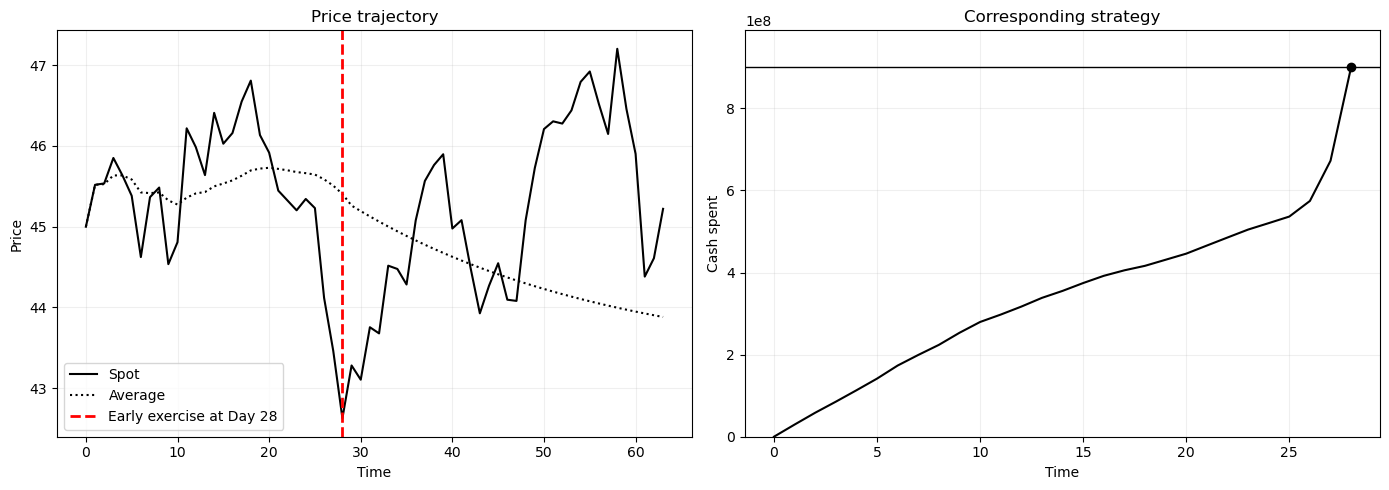

In [5]:
plot_strategy_results(model, params,generate_torch_price_paths,32)

Stopping day: 63


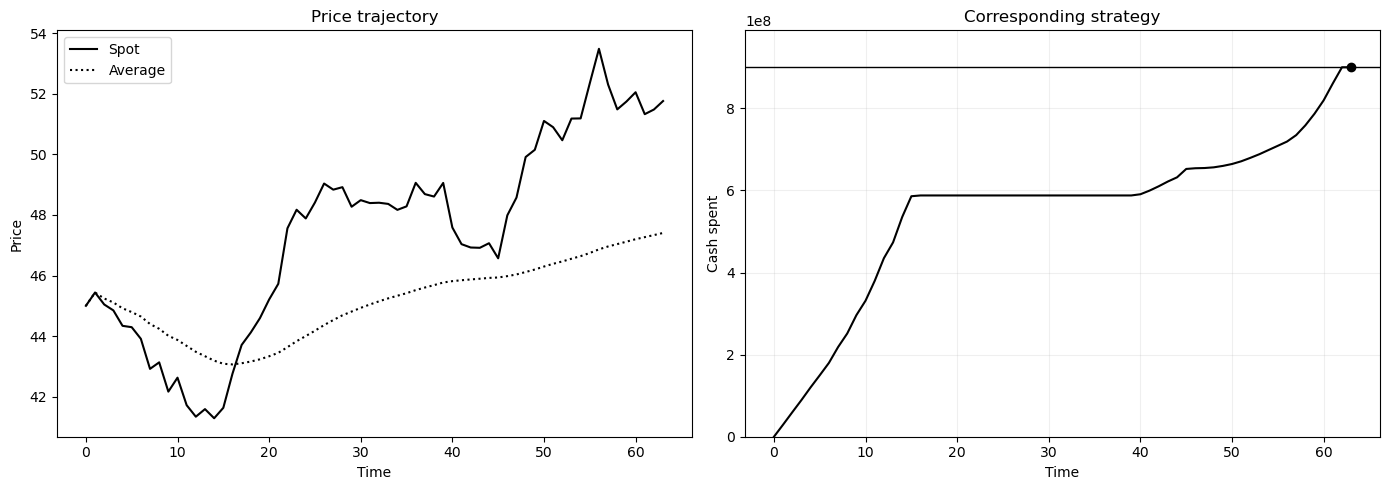

In [6]:
plot_strategy_results(model, params,generate_torch_price_paths,80)

## Set gamma to 1e-7

In [7]:
params['gamma'] = 1e-7
model_1 = trainModel(params,generate_torch_price_paths)

Epoch 0, Loss: 32851948.0000, Mean PnL: -32851948.0000, Var PnL: 1788182790144.0000
Epoch 100, Loss: -807080.5000, Mean PnL: 3166488.0000, Var PnL: 47188147175424.0000
Epoch 200, Loss: -979841.7500, Mean PnL: 3024266.7500, Var PnL: 40888499699712.0000
Epoch 300, Loss: -1341635.6250, Mean PnL: 3353182.7500, Var PnL: 40230941884416.0000
Epoch 400, Loss: -1403483.2500, Mean PnL: 3410761.0000, Var PnL: 40145554243584.0000
Epoch 500, Loss: -1473169.7500, Mean PnL: 3478055.5000, Var PnL: 40097714012160.0000
Epoch 600, Loss: -1491201.0000, Mean PnL: 3314174.5000, Var PnL: 36459469864960.0000
Epoch 700, Loss: -1602694.7500, Mean PnL: 2995645.5000, Var PnL: 27859013861376.0000
Epoch 800, Loss: -1886898.7500, Mean PnL: 3241561.0000, Var PnL: 27093245100032.0000
Epoch 900, Loss: -1880264.0000, Mean PnL: 3064774.5000, Var PnL: 23690209132544.0000
Epoch 1000, Loss: -1915280.3750, Mean PnL: 2850777.7500, Var PnL: 18709947088896.0000
Epoch 1100, Loss: -2079206.1250, Mean PnL: 2998624.0000, Var PnL: 1

Stopping day: 48


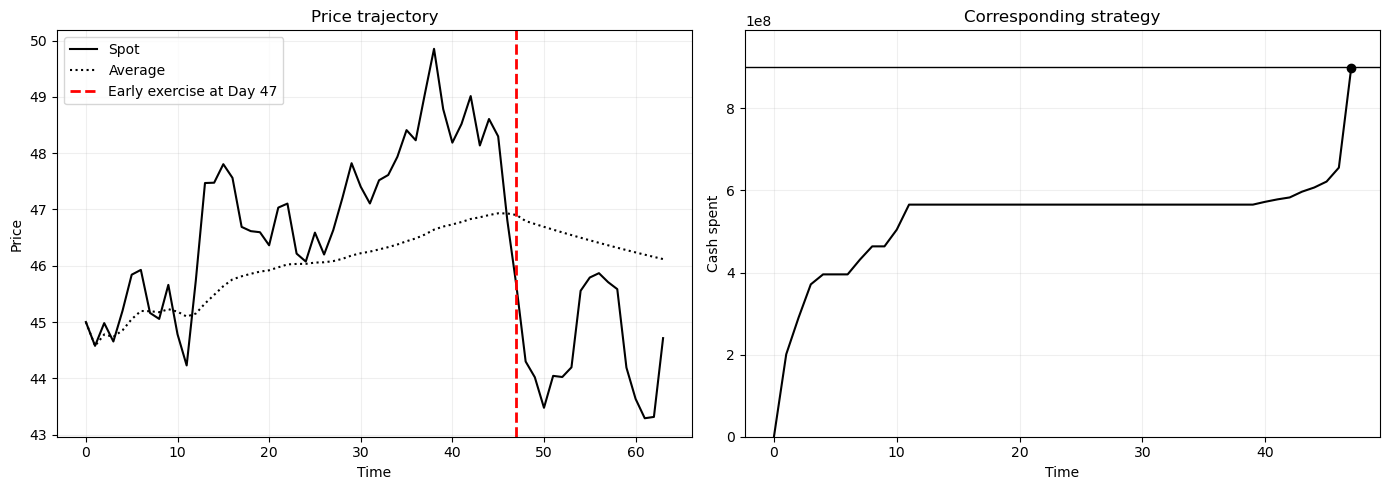

In [8]:
plot_strategy_results(model_1, params,generate_torch_price_paths,15)

## Use GBM

In [9]:
params['gamma'] = 1e-6
model_2 = trainModel(params,generate_gbm_paths_vectorised)

Epoch 0, Loss: 31577612.0000, Mean PnL: -31577612.0000, Var PnL: 655586492416.0000
Epoch 100, Loss: 6516258.0000, Mean PnL: 1441445.0000, Var PnL: 15915406065664.0000
Epoch 200, Loss: 503653.0625, Mean PnL: -231617.1562, Var PnL: 544071811072.0000
Epoch 300, Loss: 288484.5625, Mean PnL: -174338.0000, Var PnL: 228293148672.0000
Epoch 400, Loss: 276536.2500, Mean PnL: -172295.7344, Var PnL: 208480993280.0000
Epoch 500, Loss: 248074.5156, Mean PnL: -144817.9688, Var PnL: 206513094656.0000
Epoch 600, Loss: 251179.6719, Mean PnL: -161097.6719, Var PnL: 180164001792.0000
Epoch 700, Loss: 248104.4688, Mean PnL: -174418.8750, Var PnL: 147371196416.0000
Epoch 800, Loss: 248868.1094, Mean PnL: -171948.9844, Var PnL: 153838256128.0000
Epoch 900, Loss: 235285.8438, Mean PnL: -158088.5000, Var PnL: 154394689536.0000
Epoch 1000, Loss: 236895.3438, Mean PnL: -158357.9219, Var PnL: 157074849792.0000
Epoch 1100, Loss: 218308.0000, Mean PnL: -90708.5469, Var PnL: 255198904320.0000
Epoch 1200, Loss: 1752

Stopping day: 63


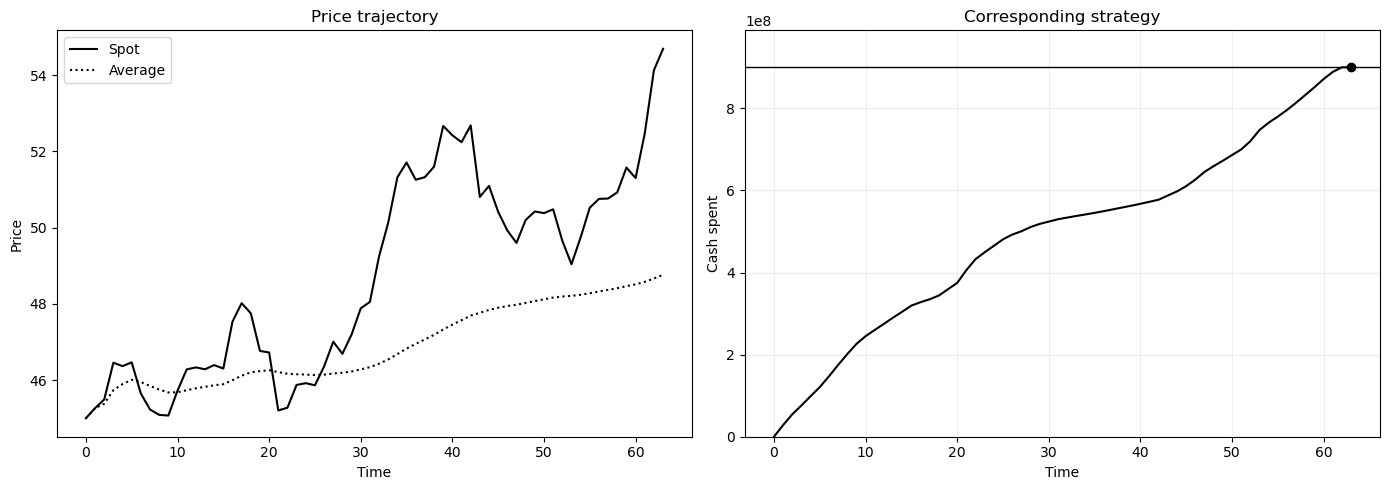

In [10]:
plot_strategy_results(model_2, params,generate_gbm_paths_vectorised,13)